# # ML - 비지도학습 - Anomaly Detection 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : 머신러닝 기법을 활용하여 집값 이싱치 탐지 실습
- 분석 단위 : 주거 지역 (동네 수준의 생활권)
- 분석 변수 : 지역의 인구·주택 정보 (인구수, 가구수, 주택 연식, 방 개수 등)

[주요 실습 내용]
- Isolation Forest

# 데이타 준비
- 분석 데이타 : 캘리포니아 집값 데이터셋
- 데이타 설명 : 캘리포니아의 작은 지역(Census Block Group)별 인구·주택 정보를 이용하여 주택 가격를 예측하기 위함
- 변수 설명
- 
| 컬럼명                | 한글명      | 의미                      | 비고               |
| ------------------ | -------- | ----------------------- | ---------------- |
| longitude          | 경도       | 해당 지역의 경도               | 연속형              |
| latitude           | 위도       | 해당 지역의 위도               | 연속형              |
| housing_median_age | 주택 중위 연식 | 해당 지역 주택의 중위 연식(년)      | 연속형              |
| total_rooms        | 전체 방 개수  | 해당 지역의 전체 방(Room) 수     | 연속형              |
| total_bedrooms     | 전체 침실 개수 | 해당 지역의 전체 침실(Bedroom) 수 | 연속형              |
| population         | 인구수      | 해당 지역의 총 인구수            | 연속형              |
| households         | 가구수      | 해당 지역의 총 가구 수           | 연속형              |
| median_income      | 중위소득     | 해당 지역 가구의 중위소득          | 연속형              |
| ocean_proximity    | 바다와의 거리  | 해당 지역의 바다와의 위치 관계       | **범주형**          |
| median_house_value | 주택 중위가격  | 해당 지역의 주택 중위가격(달러)      | **종속변수(Target)** |

- ocean_proximity 값 의미

| 값            | 의미           |
| ------------ | ------------ |
| `<1H OCEAN`  | 바다까지 1시간 이내  |
| `INLAND`     | 내륙 지역        |
| `NEAR OCEAN` | 바다 인접 지역     |
| `NEAR BAY`   | 만(Bay) 인접 지역 |
| `ISLAND`     | 섬 지역         |






데이타 불러오기

In [41]:
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


컬럼정보 확인

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

분석 변수 선택

In [43]:
cols = [
    "longitude",
    "latitude",
    "housing_median_age",
    "median_income",       # 중위소득
    "total_rooms",         # 전체 방 개수
    "population",          # 인구수
    "households",          # 가구수
    "median_house_value"   # 주택 중위가격
]

df = df[cols].copy()

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [44]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,longitude,latitude,housing_median_age,median_income,total_rooms,population,households,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,3.870671,2635.763081,1425.476744,499.539680,206855.816909
std,2.003532,2.135952,12.585558,1.899822,2181.615252,1132.462122,382.329753,115395.615874
min,-124.350000,32.540000,1.000000,0.499900,2.000000,3.000000,1.000000,14999.000000
25%,-121.800000,33.930000,18.000000,2.563400,1447.750000,787.000000,280.000000,119600.000000
50%,-118.490000,34.260000,29.000000,3.534800,2127.000000,1166.000000,409.000000,179700.000000
75%,-118.010000,37.710000,37.000000,4.743250,3148.000000,1725.000000,605.000000,264725.000000
max,-114.310000,41.950000,52.000000,15.000100,39320.000000,35682.000000,6082.000000,500001.000000


# 데이타 변환

Missing 처리
- 연속형: 중앙값 대체

In [45]:
# 연속형 변수 추출
num_cols = df.select_dtypes(include=[np.number]).columns

# 연속형 변수 중앙값 대체
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

Scaling
- Z-Score 변환

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Isolation Forest 분석
- One-Class Classification
- API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html

학습 및 예측

In [47]:
from sklearn.ensemble import IsolationForest

# 모델 정의
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # 전체 데이터 중 약 5%를 이상치로 간주
    random_state=42
)

# 이상치 학습 및 예측
df["outlier"] = iso.fit_predict(df)

# 이상치 현황
outliers = df[df["outlier"] == -1]

print("전체 개수  :", len(df))
print("이상치 개수:", len(outliers))
print("이상치 비율:", len(outliers) / len(df) * 100)

# 정상 / 이상치 label 변수 생성, -1: 이상치, 1: 정상
df["outlier_label"] = df["outlier"].map({
    1: "Normal",
    -1: "Anomaly"
})
df

전체 개수  : 20640
이상치 개수: 1032
이상치 비율: 5.0


,longitude,latitude,housing_median_age,median_income,total_rooms,population,households,median_house_value,outlier,outlier_label
0,-122.23,37.88,41.0,8.3252,880.0,322.0,126.0,452600.0,1,Normal
1,-122.22,37.86,21.0,8.3014,7099.0,2401.0,1138.0,358500.0,-1,Anomaly
2,-122.24,37.85,52.0,7.2574,1467.0,496.0,177.0,352100.0,1,Normal
3,-122.25,37.85,52.0,5.6431,1274.0,558.0,219.0,341300.0,1,Normal
4,-122.25,37.85,52.0,3.8462,1627.0,565.0,259.0,342200.0,1,Normal
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1.5603,1665.0,845.0,330.0,78100.0,1,Normal
20636,-121.21,39.49,18.0,2.5568,697.0,356.0,114.0,77100.0,1,Normal
20637,-121.22,39.43,17.0,1.7000,2254.0,1007.0,433.0,92300.0,1,Normal
20638,-121.32,39.43,18.0,1.8672,1860.0,741.0,349.0,84700.0,1,Normal


이상치 집단의 특성 분석
- EDA 분석

In [48]:
# 이상치 / 정상 비교 요약
summary = df.groupby("outlier_label")[cols].mean()

summary.round(2)

,longitude,latitude,housing_median_age,median_income,total_rooms,population,households,median_house_value
outlier_label,,,,,,,,
Anomaly,-119.65,35.78,17.88,5.90,7907.77,3815.10,1342.31,280579.76
Normal,-119.57,35.62,29.21,3.76,2358.29,1299.71,455.18,202975.61


- Decision Tree 분석

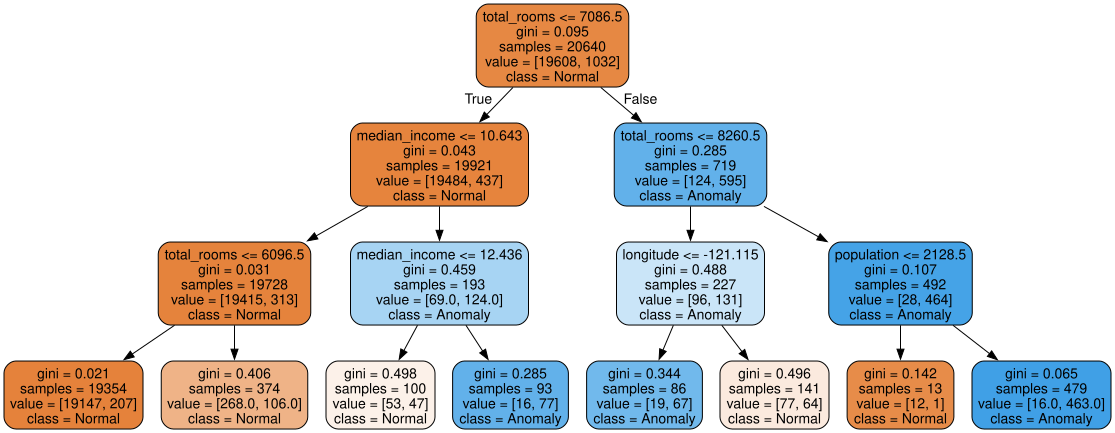

In [49]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Target 생성 (Normal=0, Anomaly=1)
df["target"] = df["outlier_label"].map({
    "Normal": 0,
    "Anomaly": 1
})

# X, y 분리
X = df.drop(['outlier_label', 'target', 'outlier'], axis=1)
y = df['target']

# 모델 정의
model = DecisionTreeClassifier(
    max_depth=3,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X, y)

# Tree 시각화 : 노드 건수 기준 출력
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X.columns,
    class_names=['Normal', 'Anomaly'],
    filled=True,
    rounded=True,
    proportion=False   # 건수 기준 출력
)
graphviz.Source(dot_data)

### [Self-Practice]

- 실습 조건
  - 분석 변수에 latitude, longitude, housing_median_age 3개를 추가해서 이상치 분석 수행, 총 8개 변수 : 기존 5개 + 신규 3개
  - 그 외 데이타 변환, 학습 조건 등은 동일 적용
- 실습 시나리오
   - 시나리오 1) 이상치 집단의 특성 분석에서 Tree 시각화 결과 Anomaly 비율이 가장 높은 집단과 가장 낮은 집단 (노드)의 규칙(Rule)을 각각 도출하세요.
   - 시나리오 2) 이상치 집단의 특성 분석에서 Normal / Anomaly 집단을 구분하는데 영향력이 큰 변수 순서는?  Random Forest 기준 Feature Importance 분석 활용

전체 방 개수가 6096.5개 보다 작거나 같으며 중위 소득이 10.643 이하일 경우 Anomaly 비율이 가장 낮으며,

전체 방 개수가 8280.5개 보다 많으며 인구 수가 2128.5명보다 많을 경우 Anomaly 비율이 가장 높았다.

In [53]:
from sklearn.model_selection import train_test_split

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 모델 정의
model = RandomForestClassifier(
    n_estimators=4,       # 트리 개수
    max_depth=4,            # 각 트리의 최대 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_prob = model.predict_proba(X_train)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

# 모델 평가 (Anomaly=1 기준)
for name, y_true, y_pred, y_prob in [
    ("Train", y_train, train_pred, train_prob),
    ("Test", y_test, test_pred, test_prob)
]:
    print(
        f"{name} | Accuracy: {accuracy_score(y_true, y_pred):.3f} | "
        f"Precision: {precision_score(y_true, y_pred, zero_division=0):.3f} | "
        f"Recall: {recall_score(y_true, y_pred, zero_division=0):.3f} | "
        f"F1: {f1_score(y_true, y_pred, zero_division=0):.3f} | "
        f"ROC-AUC: {roc_auc_score(y_true, y_prob):.3f}"
    )

Train | Accuracy: 0.980 | Precision: 0.950 | Recall: 0.632 | F1: 0.759 | ROC-AUC: 0.980
Test | Accuracy: 0.976 | Precision: 0.936 | Recall: 0.565 | F1: 0.704 | ROC-AUC: 0.966


              Feature  Importance
4         total_rooms    0.443987
6          households    0.215627
5          population    0.181086
3       median_income    0.085787
2  housing_median_age    0.037105
7  median_house_value    0.030376
0           longitude    0.003233
1            latitude    0.002799


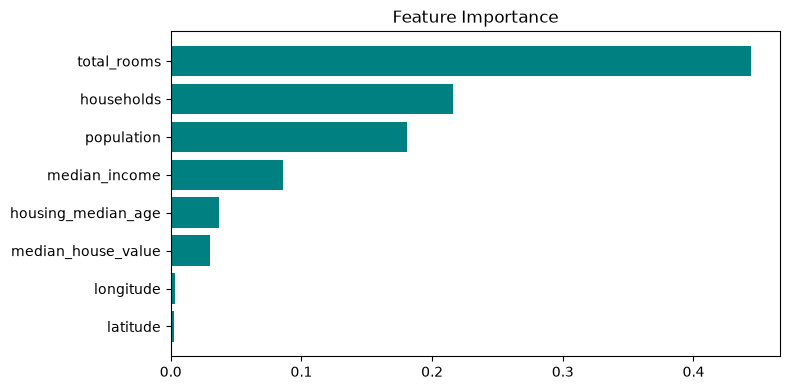

In [55]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

시나리오 2: total_rooms